In [8]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [40]:
def mixture_stats(T, subpops):
    """
    Returns:
      p_A       = total fraction of population with X > T
      p_orc_A   = fraction among *those above T* who are Orc
    """
    # Weighted sum of sub-pop contributions
    total_above = 0.0
    orc_above   = 0.0

    for (label, frac, mu, s, isOrc) in subpops:
        # Probability this subgroup is above T
        p_above = 1.0 - norm.cdf(T, loc=mu, scale=s)
        # Weighted by fraction of pop in that subgroup
        grp_contribution = frac * p_above
        total_above += grp_contribution
        if isOrc:
            orc_above += grp_contribution

    if total_above < 1e-15:
        return 0.0, 0.0  # avoid division by zero
    else:
        return total_above, orc_above / total_above

def find_threshold_for_target_pA(target_pA, subpops, lower=50, upper=150, tol=1e-7):
    """
    Finds T in [lower, upper] such that mixture_stats(T) = target_pA.
    We'll assume that as T goes down, pA goes up, so we can do a
    simple bisection search.
    """
    for _ in range(100):
        mid = 0.5*(lower + upper)
        pA, _ = mixture_stats(mid, subpops)
        if pA > target_pA:
            # threshold too low => too many violent => push threshold up
            lower = mid
        else:
            upper = mid
        if abs(pA - target_pA) < tol:
            break
    return 0.5*(lower + upper)

def find_params(subpops, p_target):
    T = find_threshold_for_target_pA(p_target, subpops, lower=50, upper=150)
    pA, p_orc_A = mixture_stats(T, subpops)
    return T, pA, p_orc_A

def plot(T, subops, x_min, x_max):
    # x_min = T - 4*sigma
    # x_max = T + 3*sigma
    x = np.linspace(x_min, x_max, 400)

    plt.figure(figsize=(8,5))

    colors = ["blue", "orange", "green", "red"]
    for (col, (label, frac, mu, s, isOrc)) in zip(colors, subpops):
        print(f"Plotting {label} with mean={mu}, stdev={s}, frac={frac}")
        pdf_vals = norm.pdf(x, loc=mu, scale=s)
        # Weighted PDF for the population mixture:
        #   Weighted by 'frac' if you want to see the actual mixture contribution
        #   Or just show the shape. We'll do fraction * pdf to see how big each is.
        plt.plot(x, pdf_vals, label=label, color=col)

    plt.axvline(T, color='k', linestyle='--', label=f'Threshold={T:.1f}')
    plt.title("Elf/Orc + Demonic Influence: Mixture PDF Components")
    plt.xlabel("Violence (IQ-scale)")
    plt.ylabel("Population Density (fraction * pdf)")
    plt.legend()
    plt.grid(True)
    plt.show()



Chosen subgroup means (IQ scale):
  ElfNo: fraction=0.765, mean=100, stdev=15, isOrc=False
  ElfYes: fraction=0.135, mean=110, stdev=15, isOrc=False
  OrcNo: fraction=0.095, mean=90, stdev=15, isOrc=True
  OrcYes: fraction=0.005000000000000001, mean=136, stdev=15, isOrc=True

Violence threshold T = 150.000 (so that 0.10% of pop are violent).
Actual fraction violent = 0.0017 (target=0.10).
Among the violent, fraction who are Orc = 0.5099. (target=0.5)
Plotting ElfNo with mean=100, stdev=15, frac=0.765
Plotting ElfYes with mean=110, stdev=15, frac=0.135
Plotting OrcNo with mean=90, stdev=15, frac=0.095
Plotting OrcYes with mean=136, stdev=15, frac=0.005000000000000001


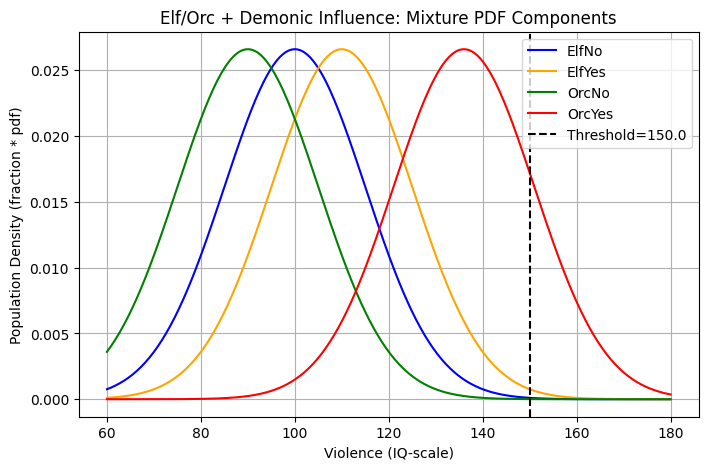

In [43]:
orc_percent = 0.10
demon_orcs = 0.05
demon_elves = 0.15

p_orc_no  = orc_percent * (1 - demon_orcs)
p_orc_yes = orc_percent * demon_orcs
p_elf_no  = (1 - orc_percent) * (1 - demon_elves)
p_elf_yes = (1 - orc_percent) * demon_elves

mu_elf_no  = 100
mu_elf_yes = 110
mu_orc_no  = 90
mu_orc_yes = 136

sigma = 15
p_target = 0.001
subpops = [
    ("ElfNo",  p_elf_no,  mu_elf_no,  sigma, False),  # (label, fraction, mean, stdev, isOrc?)
    ("ElfYes", p_elf_yes, mu_elf_yes, sigma, False),
    ("OrcNo",  p_orc_no,  mu_orc_no,  sigma, True),
    ("OrcYes", p_orc_yes, mu_orc_yes, sigma, True),
]
T, pA, p_orc_A = find_params(subpops, p_target)
print("Chosen subgroup means (IQ scale):")
for (label, frac, mu, s, isOrc) in subpops:
    print(f"  {label}: fraction={frac}, mean={mu}, stdev={s}, isOrc={isOrc}")

print(f"\nViolence threshold T = {T:.3f} (so that {p_target:.2%} of pop are violent).")
print(f"Actual fraction violent = {pA:.4f} (target=0.10).")
print(f"Among the violent, fraction who are Orc = {p_orc_A:.4f}. (target=0.5)")

plot(T, subpops, x_min = 60, x_max=180)

Chosen subgroup means (IQ scale):
  ElfNo: fraction=0.765, mean=100, stdev=15, isOrc=False
  ElfYes: fraction=0.135, mean=110, stdev=15, isOrc=False
  OrcNo: fraction=0.095, mean=90, stdev=15, isOrc=True
  OrcYes: fraction=0.005000000000000001, mean=140, stdev=15, isOrc=True

Violence threshold T = 120.943 (so that 10% of pop are violent).
Actual fraction violent = 0.1000 (target=0.10).
Among the violent, fraction who are Orc = 0.0635.
Plotting ElfNo with mean=100, stdev=15, frac=0.765
Plotting ElfYes with mean=110, stdev=15, frac=0.135
Plotting OrcNo with mean=90, stdev=15, frac=0.095
Plotting OrcYes with mean=140, stdev=15, frac=0.005000000000000001


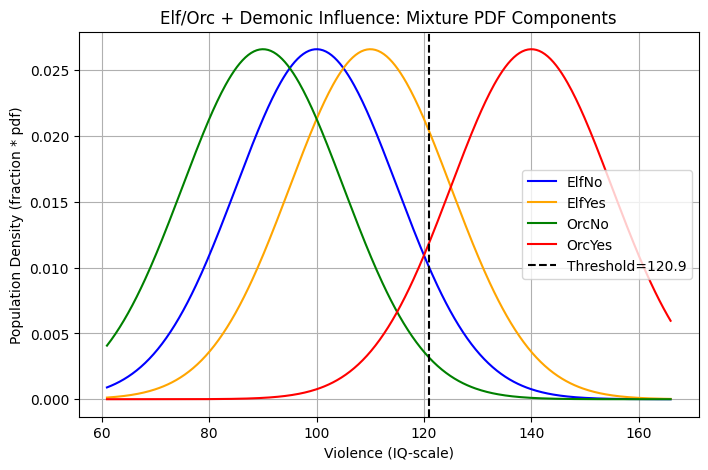

In [6]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

#----------------------------------------------------------
# 1) Define sub-populations: proportions and (mean, std).
#    We'll interpret "IQ-like" violence scale: mean in [~100..120], std=15.
#----------------------------------------------------------

# Proportions of each group in the total population.
# We'll suppose:
#   - 10% are Orcs, 90% are Elves
#   - Among Orcs, 5% are demon-influenced
#   - Among Elves, 15% are demon-influenced
#
# => Four groups (OrcNo, OrcYes, ElfNo, ElfYes) each with a fraction:
#    p(OrcNo)  = 0.10 * 0.95  = 0.095
#    p(OrcYes) = 0.10 * 0.05  = 0.005
#    p(ElfNo)  = 0.90 * 0.85  = 0.765
#    p(ElfYes) = 0.90 * 0.15  = 0.135

p_orc_no  = 0.10 * 0.95
p_orc_yes = 0.10 * 0.05
p_elf_no  = 0.90 * 0.85
p_elf_yes = 0.90 * 0.15

# For demonstration, pick some plausible "IQ-like" means:
#   - Elves (no demon) :  100
#   - Elves (demon)    :  110   (demonic influence adds +10)
#   - Orcs  (no demon) :  110   (Orcs are +10 above baseline Elves)
#   - Orcs  (demon)    :  120   (Orc + demon => +20 above baseline Elf)
#
# Each subgroup has stdev = 15.
# (You can tweak these numbers to tune who ends up "most violent".)

mu_elf_no  = 100
mu_elf_yes = 110
mu_orc_no  = 90
mu_orc_yes = 140

sigma = 15

subpops = [
    ("ElfNo",  p_elf_no,  mu_elf_no,  sigma, False),  # (label, fraction, mean, stdev, isOrc?)
    ("ElfYes", p_elf_yes, mu_elf_yes, sigma, False),
    ("OrcNo",  p_orc_no,  mu_orc_no,  sigma, True),
    ("OrcYes", p_orc_yes, mu_orc_yes, sigma, True),
]

#----------------------------------------------------------
# 2) Function to compute overall fraction above threshold T,
#    and fraction of those above T who are Orcs.
#----------------------------------------------------------
def mixture_stats(T, subpops):
    """
    Returns:
      p_A       = total fraction of population with X > T
      p_orc_A   = fraction among *those above T* who are Orc
    """
    # Weighted sum of sub-pop contributions
    total_above = 0.0
    orc_above   = 0.0

    for (label, frac, mu, s, isOrc) in subpops:
        # Probability this subgroup is above T
        p_above = 1.0 - norm.cdf(T, loc=mu, scale=s)
        # Weighted by fraction of pop in that subgroup
        grp_contribution = frac * p_above
        total_above += grp_contribution
        if isOrc:
            orc_above += grp_contribution

    if total_above < 1e-15:
        return 0.0, 0.0  # avoid division by zero
    else:
        return total_above, orc_above / total_above


#----------------------------------------------------------
# 3) We want exactly 10% of the entire population "violent"
#    => find T s.t. p_A = 0.10
#    We do a simple numeric search (bisection or Newton).
#----------------------------------------------------------
def find_threshold_for_target_pA(target_pA, subpops, lower=50, upper=150, tol=1e-7):
    """
    Finds T in [lower, upper] such that mixture_stats(T) = target_pA.
    We'll assume that as T goes down, pA goes up, so we can do a
    simple bisection search.
    """
    for _ in range(100):
        mid = 0.5*(lower + upper)
        pA, _ = mixture_stats(mid, subpops)
        if pA > target_pA:
            # threshold too low => too many violent => push threshold up
            lower = mid
        else:
            upper = mid
        if abs(pA - target_pA) < tol:
            break
    return 0.5*(lower + upper)

# We want 10% violent
p_target = 0.10
T = find_threshold_for_target_pA(p_target, subpops, lower=50, upper=150)
pA, p_orc_A = mixture_stats(T, subpops)

print("Chosen subgroup means (IQ scale):")
for (label, frac, mu, s, isOrc) in subpops:
    print(f"  {label}: fraction={frac}, mean={mu}, stdev={s}, isOrc={isOrc}")

print(f"\nViolence threshold T = {T:.3f} (so that 10% of pop are violent).")
print(f"Actual fraction violent = {pA:.4f} (target=0.10).")
print(f"Among the violent, fraction who are Orc = {p_orc_A:.4f}.")

#----------------------------------------------------------
# 4) Plot the PDFs of all subgroups on the same axis,
#    plus a vertical line for T.
#----------------------------------------------------------
x_min = T - 4*sigma
x_max = T + 3*sigma
x = np.linspace(x_min, x_max, 400)

plt.figure(figsize=(8,5))

colors = ["blue", "orange", "green", "red"]
for (col, (label, frac, mu, s, isOrc)) in zip(colors, subpops):
    print(f"Plotting {label} with mean={mu}, stdev={s}, frac={frac}")
    pdf_vals = norm.pdf(x, loc=mu, scale=s)
    # Weighted PDF for the population mixture:
    #   Weighted by 'frac' if you want to see the actual mixture contribution
    #   Or just show the shape. We'll do fraction * pdf to see how big each is.
    plt.plot(x, pdf_vals, label=label, color=col)

plt.axvline(T, color='k', linestyle='--', label=f'Threshold={T:.1f}')
plt.title("Elf/Orc + Demonic Influence: Mixture PDF Components")
plt.xlabel("Violence (IQ-scale)")
plt.ylabel("Population Density (fraction * pdf)")
plt.legend()
plt.grid(True)
plt.show()


In [51]:
# Simpson paradox example

vaccine_effectiveness_adults = 5 # Given a chance of A to be sick, it drops to A/effectiveness for adult
vaccine_effectiveness_children = 5
p_adults = 0.5 # chance for a non-vaccinated adult to be sick
p_children = 0.01 # chance for a non-vaccinated child to be sick
vaccination_rate_adults = 0.9
vaccination_rate_children = 0.1
number_of_adults = 5000
number_of_children = 5000

sick_vaccinated_adults = (number_of_adults * p_adults*vaccination_rate_adults)/vaccine_effectiveness_adults
sick_non_vaccinated_adults = (number_of_adults * p_adults*(1-vaccination_rate_adults))
sick_vaccinated_children = (number_of_children * p_children*vaccination_rate_children)/vaccine_effectiveness_children
sick_non_vaccinated_children = (number_of_children * p_children*(1-vaccination_rate_children))

print("sick_vaccinated_adults:", sick_vaccinated_adults)
print("sick_non_vaccinated_adults:", sick_non_vaccinated_adults)
print("sick_vaccinated_children:", sick_vaccinated_children)
print("sick_non_vaccinated_children:", sick_non_vaccinated_children)


sick_vaccinated_adults: 450.0
sick_non_vaccinated_adults: 249.99999999999994
sick_vaccinated_children: 1.0
sick_non_vaccinated_children: 45.0
